# Table of Contents
- [Helpers](#helpers-for-readingcleaningevaluation-of-metrics)
- [Model](#cnn-rnn-model-defination)
- [Regularization Functions](#helpers-for-regularization)
- [Training and Metrics](#training-block-with-metric-result)
- [Detection of Outliers](#detecting-outliers)
- [Displaying of Outliers](#displaying-outliers)

In [2]:
import os, random
import pandas as pd

from torch.utils.data import Subset
import numpy as np

from PIL import Image
Image.MAX_IMAGE_PIXELS = None
from PIL import ImageFile, UnidentifiedImageError
ImageFile.LOAD_TRUNCATED_IMAGES = True

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models

from torchvision.models import resnet50, ResNet50_Weights

import numpy as np
from sklearn.metrics import f1_score

INPUT_DIR = "/kaggle/input/datasets/shashiprabhapanwar/wikiart"
STYLE_INPUT_DIR = "/kaggle/input/datasets/shashiprabhapanwar/wikiart-style"
ARTIST_INPUT_DIR = "/kaggle/input/datasets/shashiprabhapanwar/wikiart-artistt"
GENRE_INPUT_DIR = "/kaggle/input/datasets/shashiprabhapanwar/wikiart-genree"

IMAGES_ROOT = os.path.join(INPUT_DIR, "wikiart_clean", "wikiart")

STYLE_TRAIN_CSV = os.path.join(STYLE_INPUT_DIR, "style_train_clean.csv")
STYLE_VAL_CSV   = os.path.join(STYLE_INPUT_DIR, "style_val_clean.csv")
STYLE_CLASS_TXT = os.path.join(STYLE_INPUT_DIR, "style_class.txt")

ARTIST_TRAIN_CSV = os.path.join(ARTIST_INPUT_DIR, "artist_train_clean.csv")
ARTIST_VAL_CSV   = os.path.join(ARTIST_INPUT_DIR, "artist_val_clean.csv")
ARTIST_CLASS_TXT = os.path.join(ARTIST_INPUT_DIR, "artist_class.txt")

GENRE_TRAIN_CSV = os.path.join(GENRE_INPUT_DIR, "genre_train_clean.csv")
GENRE_VAL_CSV   = os.path.join(GENRE_INPUT_DIR, "genre_val_clean.csv")
GENRE_CLASS_TXT = os.path.join(GENRE_INPUT_DIR, "genre_class.txt")

def read_class_names(path):
    names = {}
    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split(None, 1)
            if len(parts) == 1:
                idx = int(parts[0])
                name = str(idx)
            else:
                idx = int(parts[0])
                name = parts[1]
            names[idx] = name
    return names

style_names = read_class_names(STYLE_CLASS_TXT)
artist_names = read_class_names(ARTIST_CLASS_TXT)
genre_names = read_class_names(GENRE_CLASS_TXT)


# Helpers for Reading/Cleaning/Evaluation of Metrics

In [3]:

def read_wikiart_csv(path):
    df = pd.read_csv(path)

    if len(df.columns) == 2:
        c0, c1 = df.columns[0], df.columns[1]
        if ("/" in str(c0)) and str(c1).strip().isdigit():
            df = pd.read_csv(path, header=None, names=["relpath", "label"])
            df["label"] = df["label"].astype(int)
            return df

    df.columns = [c.strip() for c in df.columns]

    path_col = df.columns[0]
    label_col = df.columns[1]
    for c in df.columns:
        lc = c.lower()
        if lc in ["pictures", "picture", "path", "file", "filename", "image", "relpath"]:
            path_col = c
        if lc in ["class", "label", "target"]:
            label_col = c

    df = df[[path_col, label_col]].rename(columns={path_col: "relpath", label_col: "label"})
    df["label"] = df["label"].astype(int)
    return df


def build_joint_df(style_csv, artist_csv, genre_csv):
    style_df = read_wikiart_csv(style_csv).rename(columns={"label": "style_label"})
    artist_df = read_wikiart_csv(artist_csv).rename(columns={"label": "artist_label"})
    genre_df = read_wikiart_csv(genre_csv).rename(columns={"label": "genre_label"})

    df = style_df.merge(artist_df, on="relpath", how="inner")
    df = df.merge(genre_df, on="relpath", how="inner")
    return df


def filter_bad_images_multitask(df, images_root):
    good_rows = []
    bad = 0

    for row in df.itertuples(index=False):
        fullpath = os.path.join(images_root, str(row.relpath))
        try:
            with Image.open(fullpath) as im:
                im.verify()
            good_rows.append((row.relpath, int(row.style_label), int(row.artist_label), int(row.genre_label)))
        except (OSError, UnidentifiedImageError):
            bad += 1

    out = pd.DataFrame(good_rows, columns=["relpath", "style_label", "artist_label", "genre_label"])
    print(f"Filtered bad images: {bad} removed, {len(out)} remaining")
    return out


def evaluate_metrics_multitask(
    model,
    loader,
    device,
    criterion_style,
    criterion_artist,
    criterion_genre,
    use_amp=True,
):
    model.eval()

    all_style_targets = []
    all_artist_targets = []
    all_genre_targets = []

    all_style_preds = []
    all_artist_preds = []
    all_genre_preds = []

    style_top5_correct = 0
    artist_top5_correct = 0
    genre_top5_correct = 0

    joint_correct = 0
    total = 0
    val_loss_sum = 0.0

    with torch.no_grad():
        for x, y_style, y_artist, y_genre in loader:
            x = x.to(device, non_blocking=True)
            y_style = y_style.to(device, non_blocking=True)
            y_artist = y_artist.to(device, non_blocking=True)
            y_genre = y_genre.to(device, non_blocking=True)

            with torch.amp.autocast(device_type="cuda", enabled=use_amp):
                style_logits, artist_logits, genre_logits = model(x)

                style_loss = criterion_style(style_logits, y_style)
                artist_loss = criterion_artist(artist_logits, y_artist)
                genre_loss = criterion_genre(genre_logits, y_genre)

                loss = style_loss + artist_loss + genre_loss

            style_pred = style_logits.argmax(dim=1)
            artist_pred = artist_logits.argmax(dim=1)
            genre_pred = genre_logits.argmax(dim=1)

            batch_size = x.size(0)
            total += batch_size
            val_loss_sum += loss.item() * batch_size

            style_k = min(5, style_logits.size(1))
            artist_k = min(5, artist_logits.size(1))
            genre_k = min(5, genre_logits.size(1))

            style_topk = style_logits.topk(style_k, dim=1).indices
            artist_topk = artist_logits.topk(artist_k, dim=1).indices
            genre_topk = genre_logits.topk(genre_k, dim=1).indices

            style_top5_correct += (style_topk == y_style.unsqueeze(1)).any(dim=1).sum().item()
            artist_top5_correct += (artist_topk == y_artist.unsqueeze(1)).any(dim=1).sum().item()
            genre_top5_correct += (genre_topk == y_genre.unsqueeze(1)).any(dim=1).sum().item()

            joint_correct += (
                (style_pred == y_style) &
                (artist_pred == y_artist) &
                (genre_pred == y_genre)
            ).sum().item()

            all_style_targets.extend(y_style.cpu().numpy())
            all_artist_targets.extend(y_artist.cpu().numpy())
            all_genre_targets.extend(y_genre.cpu().numpy())

            all_style_preds.extend(style_pred.cpu().numpy())
            all_artist_preds.extend(artist_pred.cpu().numpy())
            all_genre_preds.extend(genre_pred.cpu().numpy())

    all_style_targets = np.array(all_style_targets)
    all_artist_targets = np.array(all_artist_targets)
    all_genre_targets = np.array(all_genre_targets)

    all_style_preds = np.array(all_style_preds)
    all_artist_preds = np.array(all_artist_preds)
    all_genre_preds = np.array(all_genre_preds)

    style_top1 = 100.0 * (all_style_preds == all_style_targets).mean()
    artist_top1 = 100.0 * (all_artist_preds == all_artist_targets).mean()
    genre_top1 = 100.0 * (all_genre_preds == all_genre_targets).mean()

    style_top5 = 100.0 * style_top5_correct / max(1, total)
    artist_top5 = 100.0 * artist_top5_correct / max(1, total)
    genre_top5 = 100.0 * genre_top5_correct / max(1, total)

    style_macro_f1 = 100.0 * f1_score(all_style_targets, all_style_preds, average="macro")
    artist_macro_f1 = 100.0 * f1_score(all_artist_targets, all_artist_preds, average="macro")
    genre_macro_f1 = 100.0 * f1_score(all_genre_targets, all_genre_preds, average="macro")

    style_weighted_f1 = 100.0 * f1_score(all_style_targets, all_style_preds, average="weighted")
    artist_weighted_f1 = 100.0 * f1_score(all_artist_targets, all_artist_preds, average="weighted")
    genre_weighted_f1 = 100.0 * f1_score(all_genre_targets, all_genre_preds, average="weighted")

    return {
        "val_loss": val_loss_sum / max(1, total),
        "joint_exact_match": 100.0 * joint_correct / max(1, total),
        "mean_top1": (style_top1 + artist_top1 + genre_top1) / 3.0,
        "mean_top5": (style_top5 + artist_top5 + genre_top5) / 3.0,
        "mean_macro_f1": (style_macro_f1 + artist_macro_f1 + genre_macro_f1) / 3.0,
        "mean_weighted_f1": (style_weighted_f1 + artist_weighted_f1 + genre_weighted_f1) / 3.0,
    }


# CNN-RNN Model Defination

In [4]:

class WikiArtMultiTaskDataset(Dataset):
    def __init__(self, df, images_root, transform=None):
        self.df = df.reset_index(drop=True).copy()
        self.images_root = images_root
        self.transform = transform
        self.df["fullpath"] = self.df["relpath"].astype(str).apply(lambda p: os.path.join(images_root, p))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["fullpath"]

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, int(row["style_label"]), int(row["artist_label"]), int(row["genre_label"])


class AttnPool1D(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.w = nn.Linear(d, 1)

    def forward(self, x):
        a = self.w(x).squeeze(-1)
        a = torch.softmax(a, dim=1).unsqueeze(-1)
        return (x * a).sum(dim=1)


class ResNet50_RowColBiGRU_MultiTask(nn.Module):
    def __init__(self, num_style_classes, num_artist_classes, num_genre_classes, proj_dim=320, rnn_hidden=256, dropout=0.4):
        super().__init__()

        base = resnet50(weights=ResNet50_Weights.DEFAULT)

        self.stem = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.proj = nn.Sequential(
            nn.Conv2d(2048, proj_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(proj_dim),
            nn.ReLU(inplace=True),
        )

        self.row_gru = nn.GRU(
            input_size=proj_dim,
            hidden_size=rnn_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2,
        )

        self.col_gru = nn.GRU(
            input_size=proj_dim,
            hidden_size=rnn_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.2,
        )

        self.row_pool = AttnPool1D(2 * rnn_hidden)
        self.col_pool = AttnPool1D(2 * rnn_hidden)

        self.dropout = nn.Dropout(dropout)

        fusion_dim = 2048 + (2 * rnn_hidden) + (2 * rnn_hidden)

        self.style_head = nn.Linear(fusion_dim, num_style_classes)
        self.artist_head = nn.Linear(fusion_dim, num_artist_classes)
        self.genre_head = nn.Linear(fusion_dim, num_genre_classes)

    def extract_fused_features(self, x):
        f = self.stem(x)

        gap = self.gap(f).flatten(1)

        z = self.proj(f)
        B, C, H, W = z.shape

        row_seq = z.permute(0, 2, 3, 1).contiguous().view(B * H, W, C)
        row_out, _ = self.row_gru(row_seq)
        row_vec = row_out.mean(dim=1).view(B, H, -1)
        row_vec = self.row_pool(row_vec)

        col_seq = z.permute(0, 3, 2, 1).contiguous().view(B * W, H, C)
        col_out, _ = self.col_gru(col_seq)
        col_vec = col_out.mean(dim=1).view(B, W, -1)
        col_vec = self.col_pool(col_vec)

        fused = torch.cat([gap, row_vec, col_vec], dim=1)
        fused = self.dropout(fused)
        return fused

    def forward(self, x):
        fused = self.extract_fused_features(x)
        style_logits = self.style_head(fused)
        artist_logits = self.artist_head(fused)
        genre_logits = self.genre_head(fused)
        return style_logits, artist_logits, genre_logits


# Helpers for Regularization

In [5]:

import math
import numpy as np
import torch
import torch.nn as nn

def rand_bbox(size, lam):
    H = size[2]
    W = size[3]

    cut_rat = np.sqrt(1.0 - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    return x1, y1, x2, y2


def apply_mixup_multitask(x, y_style, y_artist, y_genre, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0), device=x.device)

    mixed_x = lam * x + (1.0 - lam) * x[index]

    y_style_a, y_style_b = y_style, y_style[index]
    y_artist_a, y_artist_b = y_artist, y_artist[index]
    y_genre_a, y_genre_b = y_genre, y_genre[index]

    return mixed_x, y_style_a, y_style_b, y_artist_a, y_artist_b, y_genre_a, y_genre_b, lam


def apply_cutmix_multitask(x, y_style, y_artist, y_genre, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0), device=x.device)

    y_style_a, y_style_b = y_style, y_style[index]
    y_artist_a, y_artist_b = y_artist, y_artist[index]
    y_genre_a, y_genre_b = y_genre, y_genre[index]

    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    x_cut = x.clone()
    x_cut[:, :, x1:x2, y1:y2] = x[index, :, x1:x2, y1:y2]

    box_area = max(0, x2 - x1) * max(0, y2 - y1)
    lam = 1.0 - box_area / float(x.size(2) * x.size(3))

    return x_cut, y_style_a, y_style_b, y_artist_a, y_artist_b, y_genre_a, y_genre_b, lam


def mixed_criterion_multitask(
    criterion_style,
    criterion_artist,
    criterion_genre,
    style_logits,
    artist_logits,
    genre_logits,
    y_style_a,
    y_style_b,
    y_artist_a,
    y_artist_b,
    y_genre_a,
    y_genre_b,
    lam,
):
    style_loss = lam * criterion_style(style_logits, y_style_a) + (1.0 - lam) * criterion_style(style_logits, y_style_b)
    artist_loss = lam * criterion_artist(artist_logits, y_artist_a) + (1.0 - lam) * criterion_artist(artist_logits, y_artist_b)
    genre_loss = lam * criterion_genre(genre_logits, y_genre_a) + (1.0 - lam) * criterion_genre(genre_logits, y_genre_b)

    return style_loss + artist_loss + genre_loss


def maybe_apply_mix_multitask(
    x, y_style, y_artist, y_genre,
    p_mixup=0.35, p_cutmix=0.35,
    mixup_alpha=0.3, cutmix_alpha=1.0
):
    r = np.random.rand()

    if r < p_mixup:
        out = apply_mixup_multitask(x, y_style, y_artist, y_genre, alpha=mixup_alpha)
        return out, "mixup"

    if r < p_mixup + p_cutmix:
        out = apply_cutmix_multitask(x, y_style, y_artist, y_genre, alpha=cutmix_alpha)
        return out, "cutmix"

    return (x, y_style, y_style, y_artist, y_artist, y_genre, y_genre, 1.0), "none"


from collections import Counter
from torch.utils.data import WeightedRandomSampler

def make_weighted_sampler_multitask(style_labels, artist_labels, genre_labels):
    style_counts = Counter(style_labels)
    artist_counts = Counter(artist_labels)
    genre_counts = Counter(genre_labels)

    sample_weights = []
    for s, a, g in zip(style_labels, artist_labels, genre_labels):
        w_style = 1.0 / style_counts[int(s)]
        w_artist = 1.0 / artist_counts[int(a)]
        w_genre = 1.0 / genre_counts[int(g)]
        sample_weights.append((w_style + w_artist + w_genre) / 3.0)

    sample_weights = torch.DoubleTensor(sample_weights)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

def set_requires_grad(module, flag: bool):
    for p in module.parameters():
        p.requires_grad = flag

def build_optimizer(model):
    head_params = []
    for name in ["proj", "row_gru", "col_gru", "row_pool", "col_pool", "style_head", "artist_head", "genre_head"]:
        head_params += list(getattr(model, name).parameters())

    backbone_params = [p for p in model.stem.parameters() if p.requires_grad]
    head_params = [p for p in head_params if p.requires_grad]

    optimizer = optim.AdamW(
        [
            {"params": head_params, "lr": 8e-4, "weight_decay": 1e-4},
            {"params": backbone_params, "lr": 1.5e-4, "weight_decay": 1e-4},
        ]
    )
    return optimizer


# Training Block with Metric Result

In [6]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_df = build_joint_df(STYLE_TRAIN_CSV, ARTIST_TRAIN_CSV, GENRE_TRAIN_CSV)
val_df = build_joint_df(STYLE_VAL_CSV, ARTIST_VAL_CSV, GENRE_VAL_CSV)

train_df = filter_bad_images_multitask(train_df, IMAGES_ROOT)
val_df = filter_bad_images_multitask(val_df, IMAGES_ROOT)

num_style_classes = int(max(train_df["style_label"].max(), val_df["style_label"].max())) + 1
num_artist_classes = int(max(train_df["artist_label"].max(), val_df["artist_label"].max())) + 1
num_genre_classes = int(max(train_df["genre_label"].max(), val_df["genre_label"].max())) + 1

print("num_style_classes:", num_style_classes)
print("num_artist_classes:", num_artist_classes)
print("num_genre_classes:", num_genre_classes)
print("train/val sizes:", len(train_df), len(val_df))

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(384, scale=(0.7, 1.0), ratio=(0.85, 1.15)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.10, hue=0.03),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.20, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(416),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

train_dataset = WikiArtMultiTaskDataset(train_df, IMAGES_ROOT, transform=train_transform)
val_dataset = WikiArtMultiTaskDataset(val_df, IMAGES_ROOT, transform=val_transform)

train_sampler = make_weighted_sampler_multitask(
    train_df["style_label"].tolist(),
    train_df["artist_label"].tolist(),
    train_df["genre_label"].tolist()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    sampler=train_sampler,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True
)

model = ResNet50_RowColBiGRU_MultiTask(
    num_style_classes=num_style_classes,
    num_artist_classes=num_artist_classes,
    num_genre_classes=num_genre_classes,
    proj_dim=320,
    rnn_hidden=256,
    dropout=0.4
).to(device)

for i in range(4):
    set_requires_grad(model.stem[i], False)
for i in range(4, 8):
    set_requires_grad(model.stem[i], True)

criterion_style = nn.CrossEntropyLoss(label_smoothing=0.03)
criterion_artist = nn.CrossEntropyLoss(label_smoothing=0.03)
criterion_genre = nn.CrossEntropyLoss(label_smoothing=0.03)

use_amp = (device.type == "cuda")
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

epochs = 20
best_joint_exact_match = -1.0
unfreeze_epoch = 4

optimizer = build_optimizer(model)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs,
    eta_min=1e-6
)

for epoch in range(1, epochs + 1):

    model.train()
    loss_sum = 0.0
    steps = 0

    for x, y_style, y_artist, y_genre in train_loader:
        x = x.to(device, non_blocking=True)
        y_style = y_style.to(device, non_blocking=True)
        y_artist = y_artist.to(device, non_blocking=True)
        y_genre = y_genre.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        mixed_out, mix_kind = maybe_apply_mix_multitask(
            x, y_style, y_artist, y_genre,
            p_mixup=0.35,
            p_cutmix=0.35,
            mixup_alpha=0.3,
            cutmix_alpha=1.0
        )

        x_mixed, y_style_a, y_style_b, y_artist_a, y_artist_b, y_genre_a, y_genre_b, lam = mixed_out

        with torch.amp.autocast(device_type="cuda", enabled=use_amp):
            style_logits, artist_logits, genre_logits = model(x_mixed)

            if mix_kind == "none":
                loss = (
                    criterion_style(style_logits, y_style) +
                    criterion_artist(artist_logits, y_artist) +
                    criterion_genre(genre_logits, y_genre)
                )
            else:
                loss = mixed_criterion_multitask(
                    criterion_style,
                    criterion_artist,
                    criterion_genre,
                    style_logits,
                    artist_logits,
                    genre_logits,
                    y_style_a,
                    y_style_b,
                    y_artist_a,
                    y_artist_b,
                    y_genre_a,
                    y_genre_b,
                    lam,
                )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        loss_sum += loss.item()
        steps += 1

    scheduler.step()

    metrics = evaluate_metrics_multitask(
        model=model,
        loader=val_loader,
        device=device,
        criterion_style=criterion_style,
        criterion_artist=criterion_artist,
        criterion_genre=criterion_genre,
        use_amp=use_amp,
    )

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train_loss {loss_sum/max(1, steps):.4f} | "
        f"val_loss {metrics['val_loss']:.4f} | "
        f"joint_exact_match {metrics['joint_exact_match']:.2f}% | "
        f"mean_top1 {metrics['mean_top1']:.2f}% | "
        f"mean_top5 {metrics['mean_top5']:.2f}% | "
        f"mean_macro_f1 {metrics['mean_macro_f1']:.2f}% | "
        f"mean_weighted_f1 {metrics['mean_weighted_f1']:.2f}%"
    )

    if metrics["joint_exact_match"] > best_joint_exact_match:
        best_joint_exact_match = metrics["joint_exact_match"]
        torch.save(model.state_dict(), "best_general_rowcol_bigru_multitask.pt")
        print(f"Saved best checkpoint with joint_exact_match={best_joint_exact_match:.2f}%")

best_ckpt = "best_general_rowcol_bigru_multitask.pt"
model.load_state_dict(torch.load(best_ckpt, map_location=device))
model.eval()
print(f"Loaded best checkpoint: {best_ckpt}")

final_metrics = evaluate_metrics_multitask(
    model=model,
    loader=val_loader,
    device=device,
    criterion_style=criterion_style,
    criterion_artist=criterion_artist,
    criterion_genre=criterion_genre,
    use_amp=use_amp,
)

print("\n================ FINAL VALIDATION METRICS ================\n")
print(f"Validation Loss      : {final_metrics['val_loss']:.4f}")
print(f"Joint Exact Match    : {final_metrics['joint_exact_match']:.2f}%")
print(f"Mean Top-1 Accuracy  : {final_metrics['mean_top1']:.2f}%")
print(f"Mean Top-5 Accuracy  : {final_metrics['mean_top5']:.2f}%")
print(f"Mean Macro F1 Score  : {final_metrics['mean_macro_f1']:.2f}%")
print(f"Mean Weighted F1     : {final_metrics['mean_weighted_f1']:.2f}%")


Device: cuda
Filtered bad images: 0 removed, 11276 remaining
Filtered bad images: 0 removed, 4707 remaining
num_style_classes: 26
num_artist_classes: 23
num_genre_classes: 10
train/val sizes: 11276 4707
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s] 


Epoch 01/20 | train_loss 4.5548 | val_loss 2.8062 | joint_exact_match 48.69% | mean_top1 75.22% | mean_top5 97.09% | mean_macro_f1 66.35% | mean_weighted_f1 75.10%
Saved best checkpoint with joint_exact_match=48.69%
Epoch 02/20 | train_loss 3.2376 | val_loss 2.4281 | joint_exact_match 54.75% | mean_top1 79.09% | mean_top5 97.92% | mean_macro_f1 71.75% | mean_weighted_f1 79.02%
Saved best checkpoint with joint_exact_match=54.75%
Epoch 03/20 | train_loss 3.1097 | val_loss 2.2778 | joint_exact_match 57.64% | mean_top1 81.11% | mean_top5 98.34% | mean_macro_f1 72.35% | mean_weighted_f1 81.00%
Saved best checkpoint with joint_exact_match=57.64%
Epoch 04/20 | train_loss 2.7929 | val_loss 2.2613 | joint_exact_match 60.44% | mean_top1 81.93% | mean_top5 98.29% | mean_macro_f1 77.66% | mean_weighted_f1 82.20%
Saved best checkpoint with joint_exact_match=60.44%
Epoch 05/20 | train_loss 2.4986 | val_loss 2.2174 | joint_exact_match 60.34% | mean_top1 81.91% | mean_top5 98.41% | mean_macro_f1 73.37

# Detecting outliers

In [6]:

# ===== Combined outlier mining on the validation set =====
# Finds paintings that do not fit their assigned style + artist + genre jointly.

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

@torch.no_grad()
def build_embedding_table_multitask(model, df, images_root, transform, batch_size=64):
    ds = WikiArtMultiTaskDataset(df, images_root, transform=transform)
    loader = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True
    )

    model.eval()
    feats_all = []
    style_probs_all, artist_probs_all, genre_probs_all = [], [], []
    style_preds_all, artist_preds_all, genre_preds_all = [], [], []

    for x, y_style, y_artist, y_genre in loader:
        x = x.to(device, non_blocking=True)

        feats = model.extract_fused_features(x)
        feats = F.normalize(feats, dim=1)

        style_logits = model.style_head(feats)
        artist_logits = model.artist_head(feats)
        genre_logits = model.genre_head(feats)

        style_probs = torch.softmax(style_logits, dim=1)
        artist_probs = torch.softmax(artist_logits, dim=1)
        genre_probs = torch.softmax(genre_logits, dim=1)

        style_preds = style_probs.argmax(dim=1)
        artist_preds = artist_probs.argmax(dim=1)
        genre_preds = genre_probs.argmax(dim=1)

        feats_all.append(feats.cpu())

        style_probs_all.append(style_probs.cpu())
        artist_probs_all.append(artist_probs.cpu())
        genre_probs_all.append(genre_probs.cpu())

        style_preds_all.append(style_preds.cpu())
        artist_preds_all.append(artist_preds.cpu())
        genre_preds_all.append(genre_preds.cpu())

    feats_all = torch.cat(feats_all, dim=0)

    style_probs_all = torch.cat(style_probs_all, dim=0)
    artist_probs_all = torch.cat(artist_probs_all, dim=0)
    genre_probs_all = torch.cat(genre_probs_all, dim=0)

    style_preds_all = torch.cat(style_preds_all, dim=0)
    artist_preds_all = torch.cat(artist_preds_all, dim=0)
    genre_preds_all = torch.cat(genre_preds_all, dim=0)

    out = df.reset_index(drop=True).copy()

    out["pred_style_label"] = style_preds_all.numpy()
    out["pred_artist_label"] = artist_preds_all.numpy()
    out["pred_genre_label"] = genre_preds_all.numpy()

    out["true_style"] = out["style_label"].map(style_names)
    out["true_artist"] = out["artist_label"].map(artist_names)
    out["true_genre"] = out["genre_label"].map(genre_names)

    out["pred_style"] = out["pred_style_label"].map(style_names)
    out["pred_artist"] = out["pred_artist_label"].map(artist_names)
    out["pred_genre"] = out["pred_genre_label"].map(genre_names)

    style_true_idx = torch.arange(len(out))
    artist_true_idx = torch.arange(len(out))
    genre_true_idx = torch.arange(len(out))

    style_true_conf = style_probs_all[style_true_idx, torch.tensor(out["style_label"].values)].numpy()
    artist_true_conf = artist_probs_all[artist_true_idx, torch.tensor(out["artist_label"].values)].numpy()
    genre_true_conf = genre_probs_all[genre_true_idx, torch.tensor(out["genre_label"].values)].numpy()

    out["style_true_conf"] = style_true_conf
    out["artist_true_conf"] = artist_true_conf
    out["genre_true_conf"] = genre_true_conf

    out["style_mismatch"] = (out["pred_style_label"] != out["style_label"]).astype(int)
    out["artist_mismatch"] = (out["pred_artist_label"] != out["artist_label"]).astype(int)
    out["genre_mismatch"] = (out["pred_genre_label"] != out["genre_label"]).astype(int)

    out["combined_outlier_score"] = (
        (1.0 - out["style_true_conf"]) +
        (1.0 - out["artist_true_conf"]) +
        (1.0 - out["genre_true_conf"])
    ) / 3.0

    out["mismatch_count"] = out["style_mismatch"] + out["artist_mismatch"] + out["genre_mismatch"]

    out = out.sort_values(
        ["combined_outlier_score", "mismatch_count"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return out, feats_all

outliers_df, fused_feats = build_embedding_table_multitask(
    model=model,
    df=val_df,
    images_root=IMAGES_ROOT,
    transform=val_transform,
    batch_size=64
)

outliers_df.head(20)


,relpath,style_label,artist_label,genre_label,pred_style_label,pred_artist_label,pred_genre_label,true_style,true_artist,true_genre,...,pred_artist,pred_genre,style_true_conf,artist_true_conf,genre_true_conf,style_mismatch,artist_mismatch,genre_mismatch,combined_outlier_score,mismatch_count
0,Romanticism/gustave-dore_cover.jpg,23,7,3,3,15,2,Romanticism,Gustave_Dore,illustration,...,Pablo_Picasso,genre_painting,0.039617,0.041612,0.093977,1,1,1,0.941598,3
1,Impressionism/childe-hassam_the-lion-gardiner-...,12,3,2,21,10,4,Impressionism,Childe_Hassam,genre_painting,...,Ivan_Shishkin,landscape,0.044086,0.042571,0.097140,1,1,1,0.938734,3
2,Abstract_Expressionism/salvador-dali_arabs-the...,0,21,0,21,14,4,Abstract_Expressionism,Salvador_Dali,abstract_painting,...,Nicholas_Roerich,landscape,0.039636,0.049218,0.095328,1,1,1,0.938606,3
3,Realism/nicholas-roerich_demosthenes-1893.jpg,21,14,9,21,21,8,Realism,Nicholas_Roerich,still_life,...,Salvador_Dali,sketch_and_study,0.052725,0.042041,0.090483,0,1,1,0.938250,2
4,Expressionism/pablo-picasso_the-fool-1904.jpg,9,15,6,3,14,8,Expressionism,Pablo_Picasso,portrait,...,Nicholas_Roerich,sketch_and_study,0.035658,0.049679,0.100451,1,1,1,0.938070,3
5,Naive_Art_Primitivism/martiros-saryan_illustra...,15,13,3,21,22,8,Naive_Art_Primitivism,Martiros_Saryan,illustration,...,Vincent_van_Gogh,sketch_and_study,0.043079,0.045153,0.098136,1,1,1,0.937877,3
6,Expressionism/martiros-saryan_illustration-193...,9,13,3,12,22,2,Expressionism,Martiros_Saryan,illustration,...,Vincent_van_Gogh,genre_painting,0.044632,0.049053,0.092811,1,1,1,0.937835,3
7,Impressionism/salvador-dali_llane-beach-cadaqu...,12,21,4,21,22,2,Impressionism,Salvador_Dali,landscape,...,Vincent_van_Gogh,genre_painting,0.042755,0.046520,0.097400,1,1,1,0.937775,3
8,Impressionism/camille-pissarro_peasant-woman-a...,12,2,2,21,11,8,Impressionism,Camille_Pissarro,genre_painting,...,John_Singer_Sargent,sketch_and_study,0.047753,0.044044,0.095006,1,1,1,0.937732,3
9,Realism/nicholas-roerich_stuffed-duck.jpg,21,14,9,9,13,2,Realism,Nicholas_Roerich,still_life,...,Martiros_Saryan,genre_painting,0.046602,0.045468,0.094934,1,1,1,0.937665,3


# Displaying Outliers

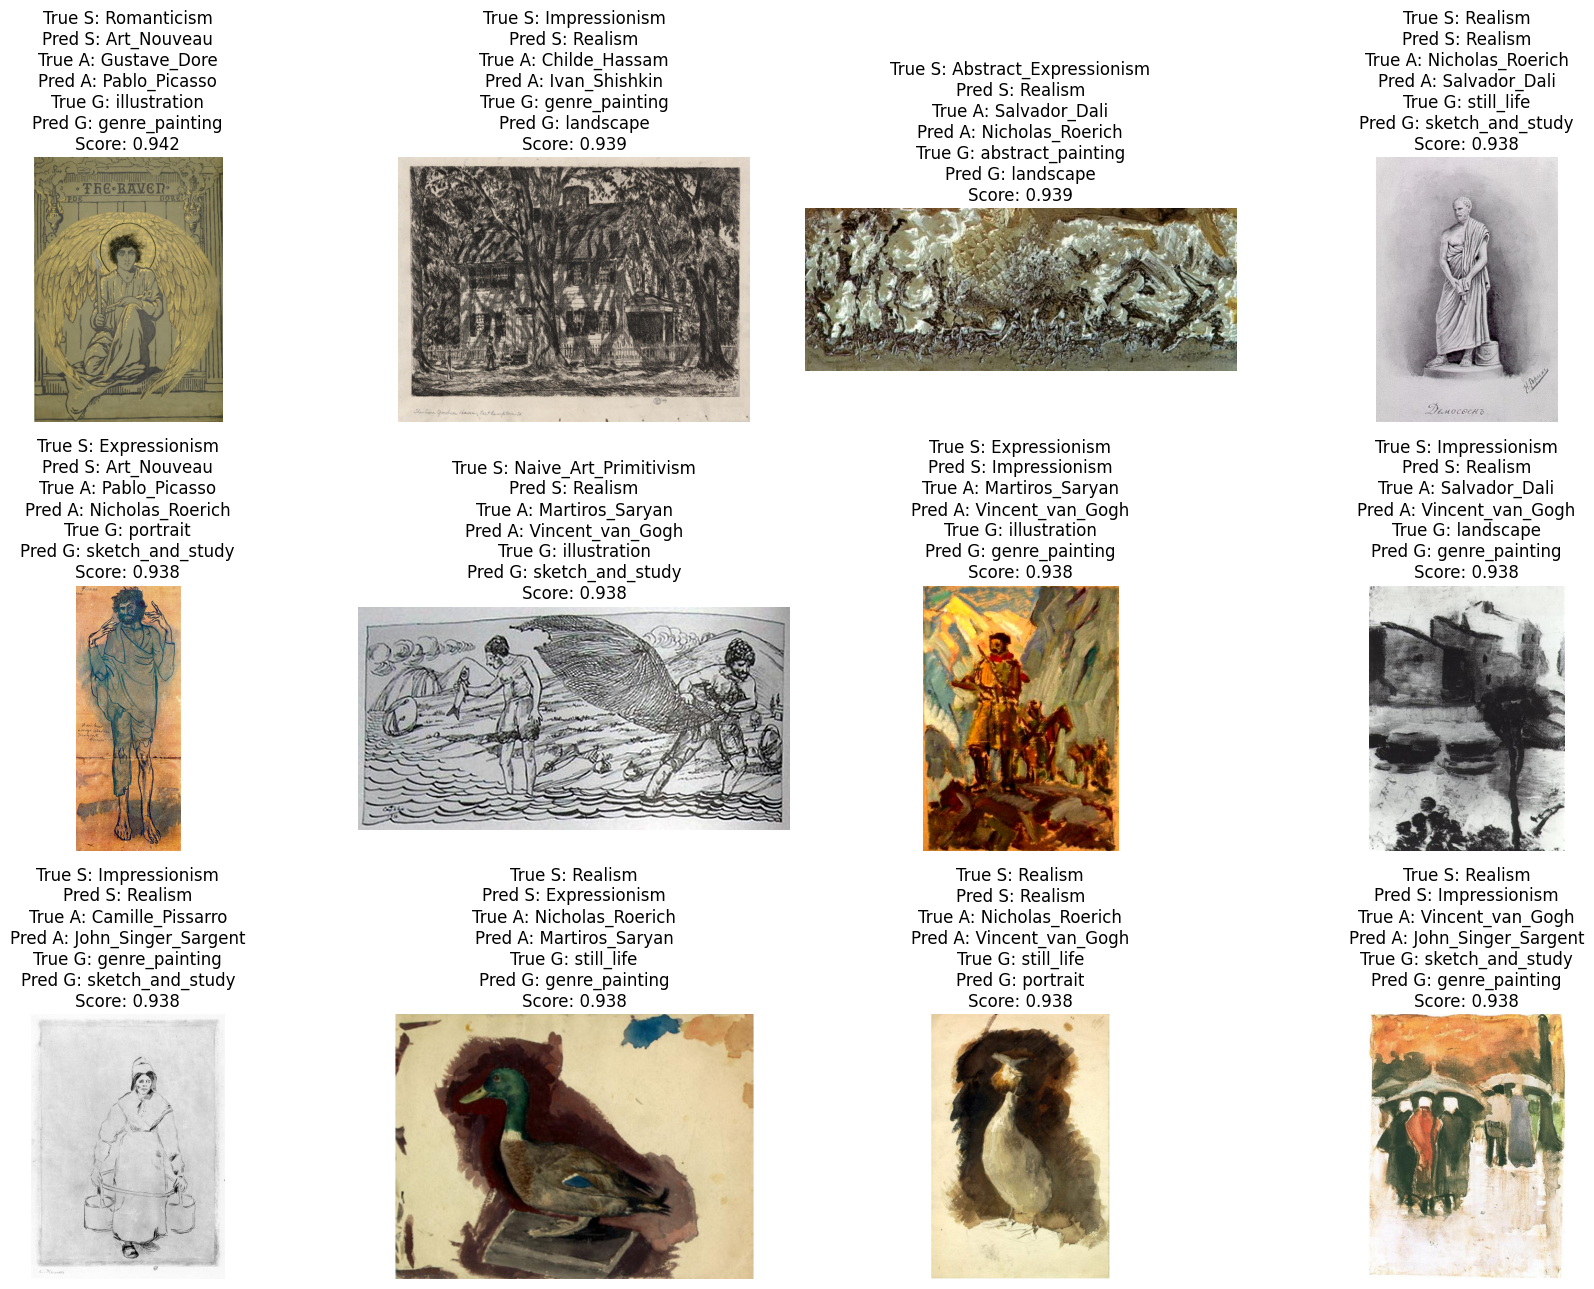

In [7]:

import matplotlib.pyplot as plt
from PIL import Image
import os

top_n = 12
rows = outliers_df.head(top_n).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
axes = axes.flatten()

for ax, (_, row) in zip(axes, rows.iterrows()):
    img = Image.open(os.path.join(IMAGES_ROOT, row["relpath"])).convert("RGB")
    ax.imshow(img)
    ax.set_title(
        f'True S: {row["true_style"]}\n'
        f'Pred S: {row["pred_style"]}\n'
        f'True A: {row["true_artist"]}\n'
        f'Pred A: {row["pred_artist"]}\n'
        f'True G: {row["true_genre"]}\n'
        f'Pred G: {row["pred_genre"]}\n'
        f'Score: {row["combined_outlier_score"]:.3f}'
    )
    ax.axis("off")

for ax in axes[len(rows):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
